# Plotting examples

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3.common.results_plotter import (
    load_results,
    ts2xy,
    window_func,
)

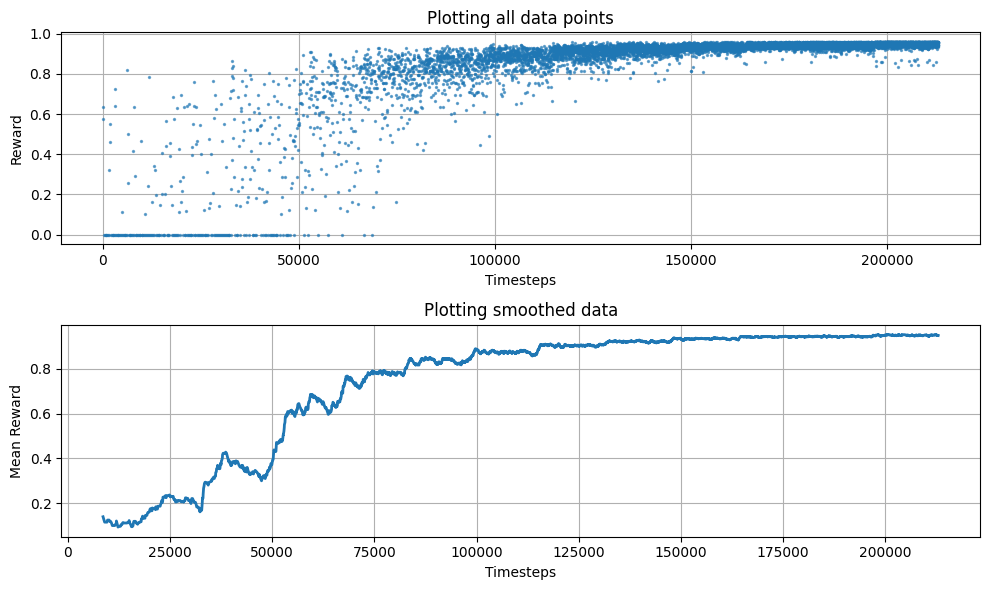

In [15]:
log_dir = Path("../../logs/")
df = load_results(log_dir)
x, y = ts2xy(df, "timesteps")
data_limit = 50

# Plot raw data
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.scatter(x, y, s=2, alpha=0.6, zorder=2)
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.grid(zorder=1)
plt.title("Plotting all data points")

# Plot smoothed data with custom window
plt.subplot(2, 1, 2)
if len(x) >= data_limit:  # Only smooth if we have enough data
    x_smooth, y_smooth = window_func(x, y, data_limit, np.mean)
    plt.plot(x_smooth, y_smooth, linewidth=2, zorder=2)
    plt.xlabel("Timesteps")
    plt.ylabel("Mean Reward")
    plt.grid(zorder=1)
    plt.title("Plotting smoothed data")

plt.tight_layout()
plt.show()